### Analyzing Pet Adoption Trends and Factors - Gaby Castellanos

Animals shelters are currently facing an overcrowding crisis as many pets are being surrounded to animal shelters but not enough people are adopting. This leads some to resort to controversial methods to reduce overcrowding. It's often unclear which pet characteristics and circumstances are most influential on whether a pet is adopted or not. This project aims to analyze pet shelter data to identify the most common key factors that affect the likelihood of a pet being adopted. The factors relating to a pet's amount of time spent in a shelter will also be examined. The variables included in the dataset are PetID, PetType, Breed, AgeMonths, Color, Size, Weightkg, Vaccinated, HealthCondition, TimeInShelterDays, AdoptionFee, PreviousOwner, and AdoptionLikelihood. With the exploration and analysis of the dataset, hopefully the key factors will reveal what is needed to improve adoption outcomes. This project will be done individually.

In [112]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [113]:
# Import packages, load the pet_adoption_data dataset, and view the data
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

PetAdoptionData = pd.read_csv('/content/drive/My Drive/Colab Notebooks/pet_adoption_data.csv')
PetAdoptionData.head()

,PetID,PetType,Breed,AgeMonths,Color,Size,WeightKg,Vaccinated,HealthCondition,TimeInShelterDays,AdoptionFee,PreviousOwner,AdoptionLikelihood
0,500,Bird,Parakeet,131,Orange,Large,5.039768,1,0,27,140,0,0
1,501,Rabbit,Rabbit,73,White,Large,16.086727,0,0,8,235,0,0
2,502,Dog,Golden Retriever,136,Orange,Medium,2.076286,0,0,85,385,0,0
3,503,Bird,Parakeet,97,White,Small,3.339423,0,0,61,217,1,0
4,504,Rabbit,Rabbit,123,Gray,Large,20.498100,0,0,28,14,1,0


In [114]:
# Look over the data information and descriptive statistics
PetAdoptionData.info()
PetAdoptionData.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2007 entries, 0 to 2006
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   PetID               2007 non-null   int64  
 1   PetType             2007 non-null   object 
 2   Breed               2007 non-null   object 
 3   AgeMonths           2007 non-null   int64  
 4   Color               2007 non-null   object 
 5   Size                2007 non-null   object 
 6   WeightKg            2007 non-null   float64
 7   Vaccinated          2007 non-null   int64  
 8   HealthCondition     2007 non-null   int64  
 9   TimeInShelterDays   2007 non-null   int64  
 10  AdoptionFee         2007 non-null   int64  
 11  PreviousOwner       2007 non-null   int64  
 12  AdoptionLikelihood  2007 non-null   int64  
dtypes: float64(1), int64(8), object(4)
memory usage: 204.0+ KB


,PetID,AgeMonths,WeightKg,Vaccinated,HealthCondition,TimeInShelterDays,AdoptionFee,PreviousOwner,AdoptionLikelihood
count,2007.000000,2007.000000,2007.000000,2007.000000,2007.000000,2007.000000,2007.000000,2007.000000,2007.000000
mean,1503.000000,92.279522,15.705776,0.701046,0.196313,43.974091,249.142003,0.301943,0.328351
std,579.515315,52.148363,8.327749,0.457914,0.397307,25.740253,142.887040,0.459215,0.469730
min,500.000000,1.000000,1.018198,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,1001.500000,48.000000,8.730396,0.000000,0.000000,21.000000,127.000000,0.000000,0.000000
50%,1503.000000,94.000000,15.925416,1.000000,0.000000,45.000000,242.000000,0.000000,0.000000
75%,2004.500000,138.000000,22.737180,1.000000,0.000000,66.000000,375.000000,1.000000,1.000000
max,2506.000000,179.000000,29.995628,1.000000,1.000000,89.000000,499.000000,1.000000,1.000000


In [115]:
# Check for missing values
PetAdoptionData.isnull().sum()

,0
PetID,0
PetType,0
Breed,0
AgeMonths,0
Color,0
Size,0
WeightKg,0
Vaccinated,0
HealthCondition,0
TimeInShelterDays,0


There are no missing values in any of the columns.

In [116]:
# Check data types
PetAdoptionData.dtypes

,0
PetID,int64
PetType,object
Breed,object
AgeMonths,int64
Color,object
Size,object
WeightKg,float64
Vaccinated,int64
HealthCondition,int64
TimeInShelterDays,int64


In [117]:
# Check for outliers
Q1 = PetAdoptionData['TimeInShelterDays'].quantile(0.25)
Q3 = PetAdoptionData['TimeInShelterDays'].quantile(0.75)
IQR = Q3 - Q1

outliers = PetAdoptionData[((PetAdoptionData['TimeInShelterDays']
                             < (Q1 - 1.5 * IQR)) |
                              (PetAdoptionData['TimeInShelterDays'] >
                               (Q3 + 1.5 * IQR)))]
outliers

,PetID,PetType,Breed,AgeMonths,Color,Size,WeightKg,Vaccinated,HealthCondition,TimeInShelterDays,AdoptionFee,PreviousOwner,AdoptionLikelihood


There seems to be no outliers for any category when using the quantile method.

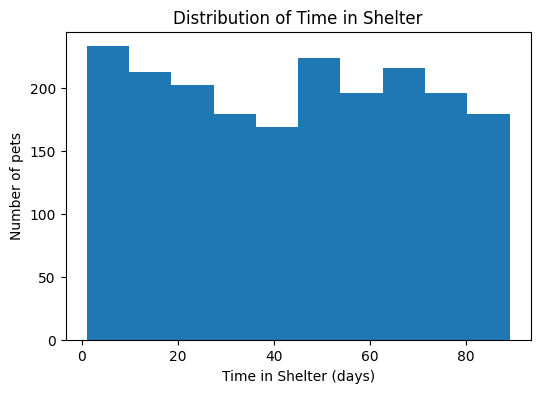

In [118]:
# Visualization of the TimeInShelterDays
plt.figure(figsize=(6, 4))
plt.hist(PetAdoptionData['TimeInShelterDays'])
plt.xlabel('Time in Shelter (days)')
plt.ylabel('Number of pets')
plt.title('Distribution of Time in Shelter')
plt.show()

The distribution of time in shelter appears to be fairly distributed, which suggests that longer and shorter stays occur with similar frequency. Adoption time may depend on a combination of factors.

Text(0.5, 1.0, 'Vaccinated vs. AdoptionLikelihood')

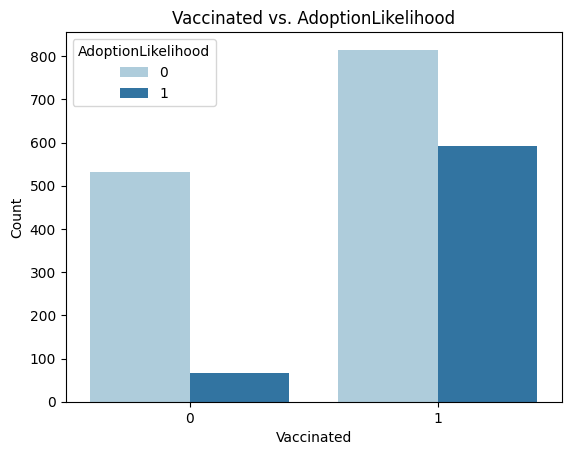

In [119]:
# Vaccinated vs. AdoptionLikelihood
sns.countplot(x='Vaccinated', hue='AdoptionLikelihood',
              data=PetAdoptionData, palette='Paired')
plt.xlabel('Vaccinated')
plt.ylabel('Count')
plt.title('Vaccinated vs. AdoptionLikelihood')

The count plot shows that vaccinated pets tend to have a higher number of successful adoptions compared to unvaccinated pets. While both groups include a high number of pets that weren't adopted, the proportion of adopted pets is noticeably higher among those that are vaccinated.

Text(0.5, 1.0, 'Size vs. Adoption Likelihood')

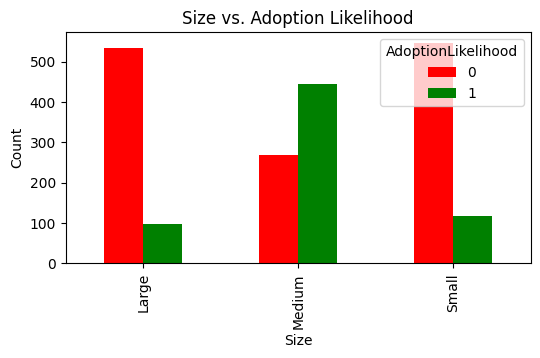

In [120]:
# Size vs Adoption Likelihood
PetAdoptionData.groupby(
    ['Size', 'AdoptionLikelihood']).size().unstack().plot(kind="bar"
    , color=['red', 'green'], figsize=(6, 3))

plt.xlabel('Size')
plt.ylabel('Count')
plt.title('Size vs. Adoption Likelihood')

There is a high number of large and small pets that don't get adopted while there is a lower number for medium pets. They also have the highest adoption numbers. This suggests that medium sized pets are the most desirable size for pets.

Text(0.5, 1.0, 'Previous Owner vs. Adoption Likelihood')

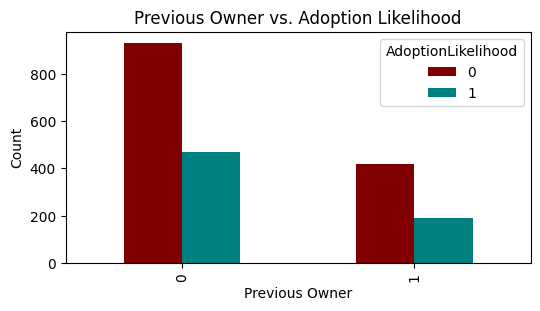

In [121]:
# Previous Owner vs Adoption Likelihood
PetAdoptionData.groupby(
    ['PreviousOwner', 'AdoptionLikelihood']).size().unstack().plot(kind="bar"
    , color=['maroon', 'teal'], figsize=(6, 3))
plt.xlabel('Previous Owner')
plt.ylabel('Count')
plt.title('Previous Owner vs. Adoption Likelihood')

The bar chart shows that an extremely high number of pets that don't have previous owners are not adopted, which is a surprise. However, out of the pets that do get adopted, not having a previous owner seems to be favorable.

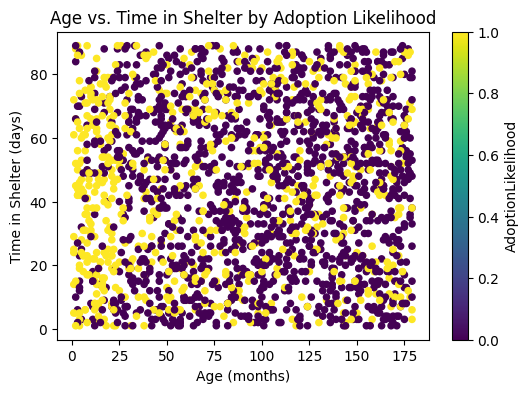

In [122]:
# Age vs Time in Shelter by Adoption Likelihood
PetAdoptionData.plot(kind='scatter', x='AgeMonths', y='TimeInShelterDays',
                     c='AdoptionLikelihood', colormap='viridis', figsize=(6, 4))
plt.xlabel('Age (months)')
plt.ylabel('Time in Shelter (days)')
plt.title('Age vs. Time in Shelter by Adoption Likelihood')
plt.show()

The scatter plot shows almost no correlation between a pet's age and their time in the shelter. However, the yellow dots being slightly more visible on the left side of the scatter plot may suggest that pets under 25 months old have a higher adoption likelihood.

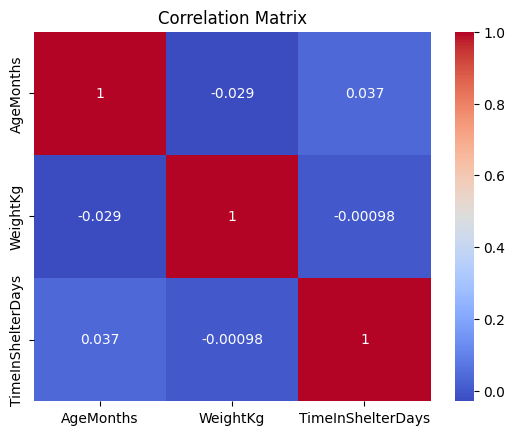

In [123]:
# Correlation Matrix
sns.heatmap(PetAdoptionData[['AgeMonths', 'WeightKg',
                             'TimeInShelterDays']].corr(),
            annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

The correlation matrix shows the relationships between a pet's age, weight, and time in the shelter. Since all the values are lose to 0, there seems to be a weak relationship between them. Overall, this may suggest that the numerical features alone aren't strong predictors of adoption outcomes or shelter time duration.

In [124]:
# Create a copy of PetAdoptionData to use for modeling
PetAdoptionData_copy = PetAdoptionData.copy()

In [125]:
# Drop ID column because it is not needed for prediction
PAD = PetAdoptionData_copy.drop(columns=['PetID'], errors="ignore")

In [126]:
# Convert categorical variable into numeric variables.
# This makes it easier to build a model
PetAdoptionData_encoded = pd.get_dummies(PAD, drop_first=True)
PetAdoptionData_encoded.head()

,AgeMonths,WeightKg,Vaccinated,HealthCondition,TimeInShelterDays,AdoptionFee,PreviousOwner,AdoptionLikelihood,PetType_Cat,PetType_Dog,...,Breed_Persian,Breed_Poodle,Breed_Rabbit,Breed_Siamese,Color_Brown,Color_Gray,Color_Orange,Color_White,Size_Medium,Size_Small
0,131,5.039768,1,0,27,140,0,0,False,False,...,False,False,False,False,False,False,True,False,False,False
1,73,16.086727,0,0,8,235,0,0,False,False,...,False,False,True,False,False,False,False,True,False,False
2,136,2.076286,0,0,85,385,0,0,False,True,...,False,False,False,False,False,False,True,False,True,False
3,97,3.339423,0,0,61,217,1,0,False,False,...,False,False,False,False,False,False,False,True,False,True
4,123,20.498100,0,0,28,14,1,0,False,False,...,False,False,True,False,False,True,False,False,False,False


In [127]:
# Define features and target

# AdoptionLikelihood is removed because it is what I am trying
# to predict
X = PetAdoptionData_encoded.drop(columns=['AdoptionLikelihood'])

# AdoptionLikelihood is what the model is learning to predict
y = PetAdoptionData_encoded['AdoptionLikelihood']

In [128]:
# Split data into training data used to build the model
# and Testing data used to evaluate the model

# 20% of the data is used for testing while the rest is used
# for training
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42)

In [129]:
# Scale the data

# Puts the numeric features on a similar scale, which helps
# the logistic regression run more smoothly
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [130]:
# Train the model

# Logistic regression is used as a classification model to
# predict AdoptionLikelihood
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

In [131]:
# Model accuracy
y_pred = model.predict(X_test)
accuracy_score(y_test, y_pred)

0.9079601990049752

The accuracy of the model is about 91%, which shows a high percentage of correct predictions. However, the accuracy shouln't be the only thing used to see if AdoptionLikelihood was predicted well.

In [132]:
# Classification Report
print(classification_report(y_test, y_pred))
confusion_matrix(y_test, y_pred)

              precision    recall  f1-score   support

           0       0.90      0.97      0.93       270
           1       0.94      0.77      0.85       132

    accuracy                           0.91       402
   macro avg       0.92      0.87      0.89       402
weighted avg       0.91      0.91      0.91       402



array([[263,   7],
       [ 30, 102]])

The classification report gves more insight than the accuracy score. When the model predicts 0 (a lower likelihood of adoption), the precision is 91%, which shows a high accuracy. The same goes for the 89% precision for the model predicting 1 (high likelihood of adoption). The high recall percentages for 0 and 1 show that the model finds most of the actual cases, but it is defintely better at finding cases with 0. The high f1-scores show strong balances between precision and recall, but the balance is stronger with 0. For cases with 0, the model predicted 257 accurately and 13 inaccurately (false positive). For cases with 1, the model predicted 107 accurately and 25 inaccurately (false negative). Overall, the model is slightly better at predicting a pet not getting adopted compared to a pet being adopted.

In [137]:
# Highlighting important features

# The absolute values are focused on to find the strongest predictors overall
coefficients = pd.DataFrame({'Feature': X.columns,
                             'Coefficient': model.coef_[0]})

# By using AbsoluteCoefficient, whether a relationship is positive or negative
# is ignored, which helps rank the features by overall strength.
coefficients['AbsoluteCoefficient'] = coefficients['Coefficient'].abs()
coefficients = coefficients.sort_values(by='Coefficient', ascending=False)


mostImportantFeatures = coefficients.sort_values(by='AbsoluteCoefficient',
                                                 ascending=False).head(10)
mostImportantFeatures

,Feature,Coefficient,AbsoluteCoefficient
20,Size_Medium,1.729140,1.729140
2,Vaccinated,1.498223,1.498223
3,HealthCondition,-1.400746,1.400746
10,Breed_Labrador,0.930976,0.930976
0,AgeMonths,-0.748107,0.748107
8,PetType_Dog,0.129551,0.129551
12,Breed_Persian,-0.114004,0.114004
5,AdoptionFee,-0.110220,0.110220
17,Color_Gray,-0.098036,0.098036
21,Size_Small,0.095322,0.095322


In the chart, the positive coefficients show an increased likelihood of adoption while the negative coefficients show a decreased likelihood of adoption. The absolute coefficients show the strengths of influence of the features. The features with larger absolute coefficients have a stronger influence on pet adoptions. From the chart, a medium sized pet seems to be the most influential feature when adopting a pet, followed by vaccination status and health condition. The large positive coefficients for Size_Medium and Vaccinated indicate that there is a preference for medium sized pets and vaccinated pets when looking at pet adoptions. The large negative coefficient for HealthCondition suggests that pets with poorer health conditions are less likely to be adopted.

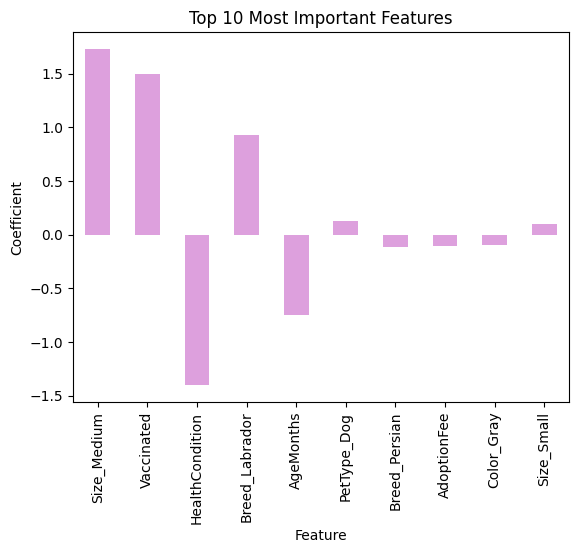

In [142]:
# Visualization of the top features
mostImportantFeatures.plot(kind='bar', x='Feature', y='Coefficient',
                           legend=False, color='plum')
plt.xlabel('Feature')
plt.ylabel('Coefficient')
plt.title('Top 10 Most Important Features')
plt.show()

# References
Feature Importance in Logistic Regression Models:
https://www.geeksforgeeks.org/machine-learning/understanding-feature-importance-in-logistic-regression-models/


Classification Report and Confusion Matrix:
https://www.geeksforgeeks.org/machine-learning/compute-classification-report-and-confusion-matrix-in-python/


Git Repo:
https://github.com/gcastellanos1/CSC108-MATH80-Repo

